## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 2. Load Dataset

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 3. Basic Dataset Understanding

In [3]:
df.shape

(4000, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [5]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## 4. Data Cleaning

In [6]:
# Check missing values
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [7]:

df.duplicated().sum()

np.int64(0)

In [8]:

df = df.drop_duplicates()
print("Dataset shape:", df.shape)

Dataset shape: (4000, 28)


## 5. Exploratory Data Analysis

### 5.1 Season Distribution

In [9]:
df["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

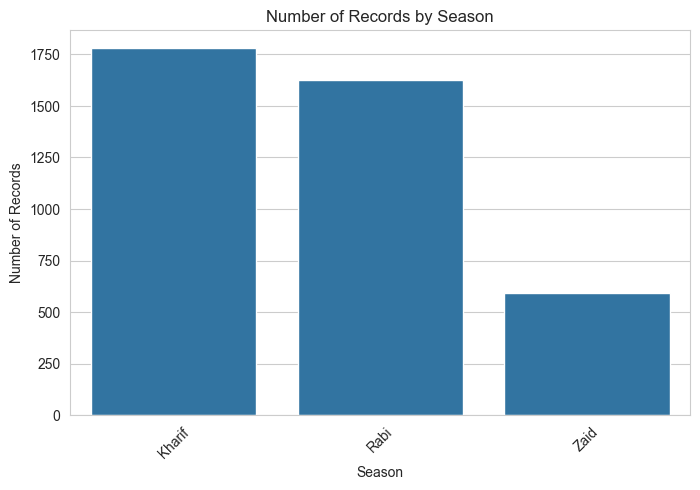

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Season")
plt.title("Number of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

### 5.2 Average Crop Yield by Season

In [11]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
season_yield

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64

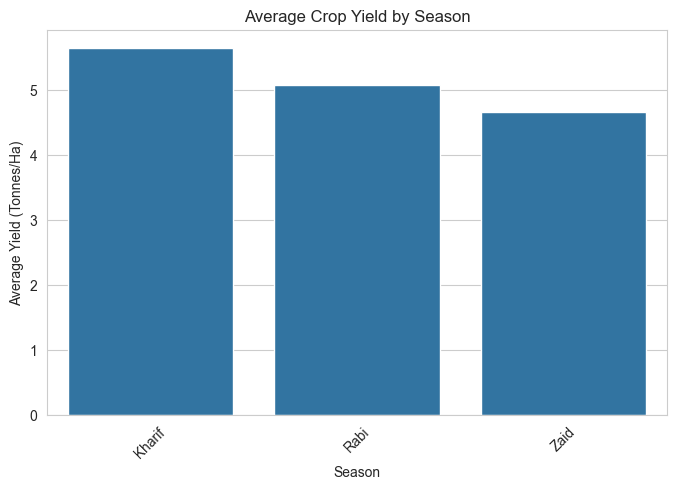

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x=season_yield.index, y=season_yield.values)
plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

### 5.3 Average Profit by Season

In [13]:
season_profit = df.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)
season_profit

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

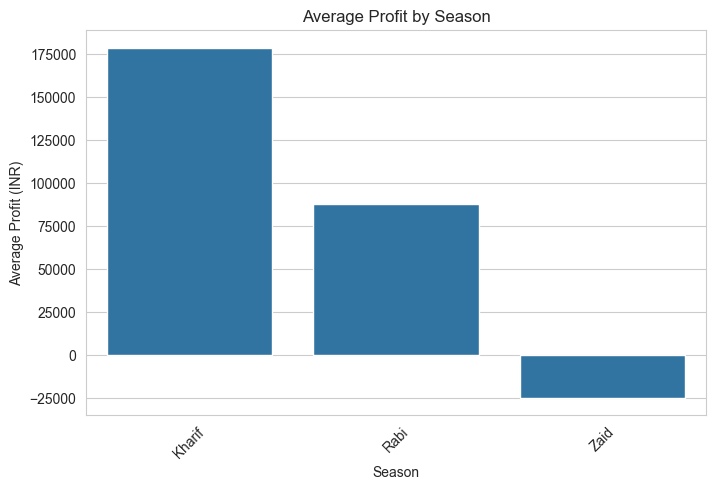

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x=season_profit.index, y=season_profit.values)
plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.show()

### 5.4 Average Production by Season

In [15]:
season_production = df.groupby("Season")["Production_Tonnes"].mean().sort_values(ascending=False)
season_production

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64

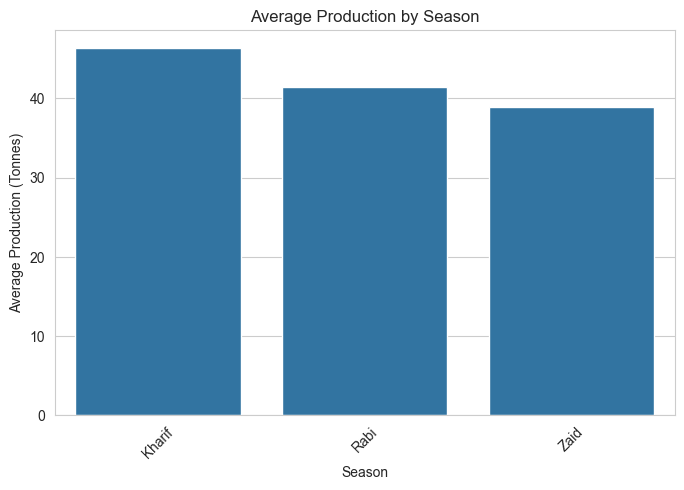

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x=season_production.index, y=season_production.values)
plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.xticks(rotation=45)
plt.show()

### 5.5 Average Rainfall by Season

In [17]:
season_rainfall = df.groupby("Season")["Rainfall_mm"].mean().sort_values(ascending=False)
season_rainfall

Season
Kharif    852.084205
Rabi      436.000124
Zaid      299.421784
Name: Rainfall_mm, dtype: float64

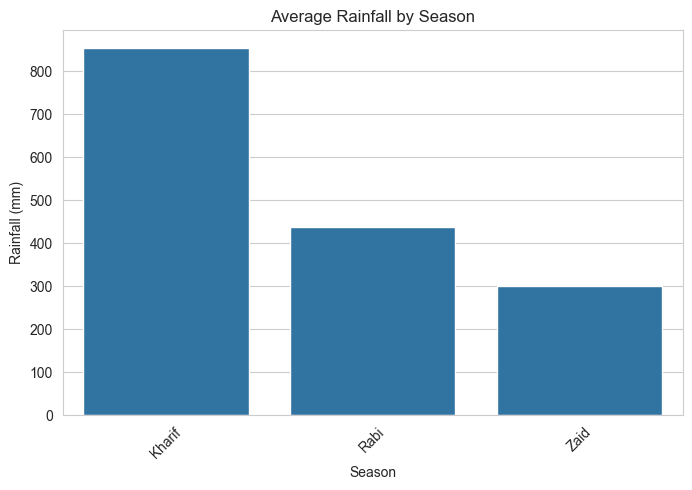

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(x=season_rainfall.index, y=season_rainfall.values)
plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=45)
plt.show()

### 5.6 Average Temperature by Season

In [19]:
season_temperature = df.groupby("Season")["Avg_Temperature_C"].mean().sort_values(ascending=False)
season_temperature

Season
Zaid      31.042088
Kharif    28.454019
Rabi      23.489183
Name: Avg_Temperature_C, dtype: float64

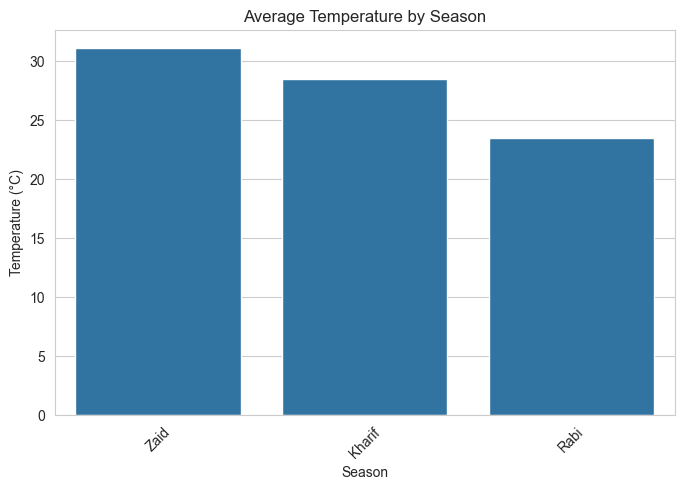

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x=season_temperature.index, y=season_temperature.values)
plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.show()

### 5.7 Average Water Usage by Season

In [21]:
season_water = df.groupby("Season")["Water_Used_m3"].mean().sort_values(ascending=False)
season_water

Season
Zaid      6419.893939
Kharif    6102.201237
Rabi      5846.987093
Name: Water_Used_m3, dtype: float64

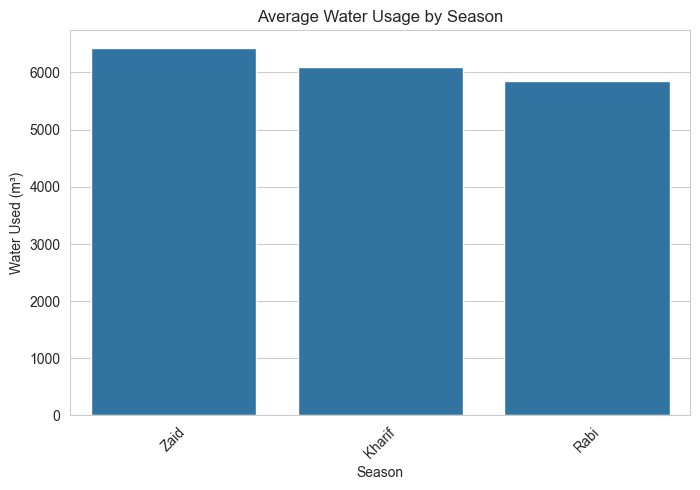

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x=season_water.index, y=season_water.values)
plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=45)
plt.show()

### 5.8 Crop Distribution

In [23]:
df["Crop"].value_counts()

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

### 5.9 Average Yield by Crop

In [24]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
crop_yield

Crop
Sugarcane    46.938746
Maize         2.717130
Rice          2.439413
Wheat         2.109216
Chilli        1.540344
Groundnut     1.317924
Cotton        1.225734
Pulses        0.918198
Name: Yield_Tonnes_Ha, dtype: float64

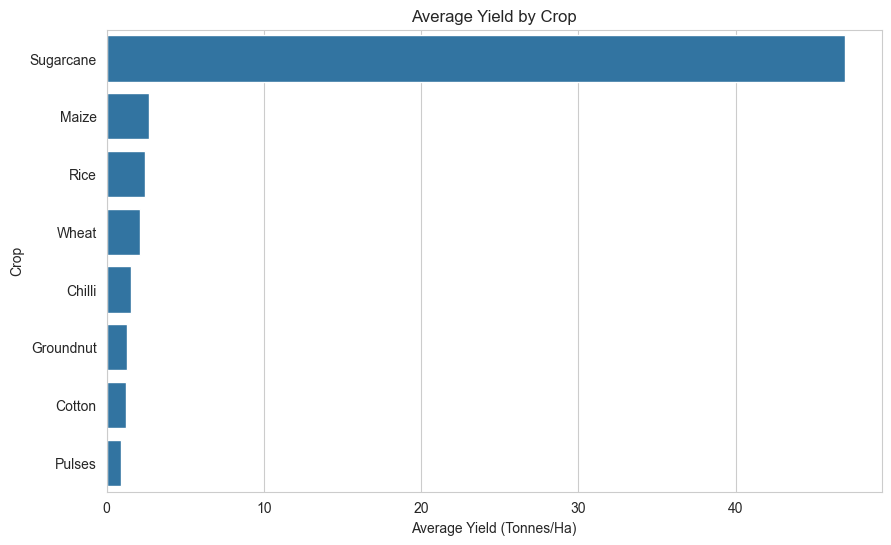

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x=crop_yield.values, y=crop_yield.index)
plt.title("Average Yield by Crop")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")
plt.show()

### 5.10 Crop Yield by Season

In [26]:
crop_season_yield = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)
crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731413,1.461615,1.177742
Cotton,1.372804,1.192915,0.951648
Groundnut,1.483646,1.221445,1.037778
Maize,2.966410,2.614913,2.297590
Pulses,1.036063,0.871887,0.652131
Rice,2.707621,2.333680,1.900490
Sugarcane,53.459120,43.940394,38.423922
Wheat,2.255430,2.058814,1.748588


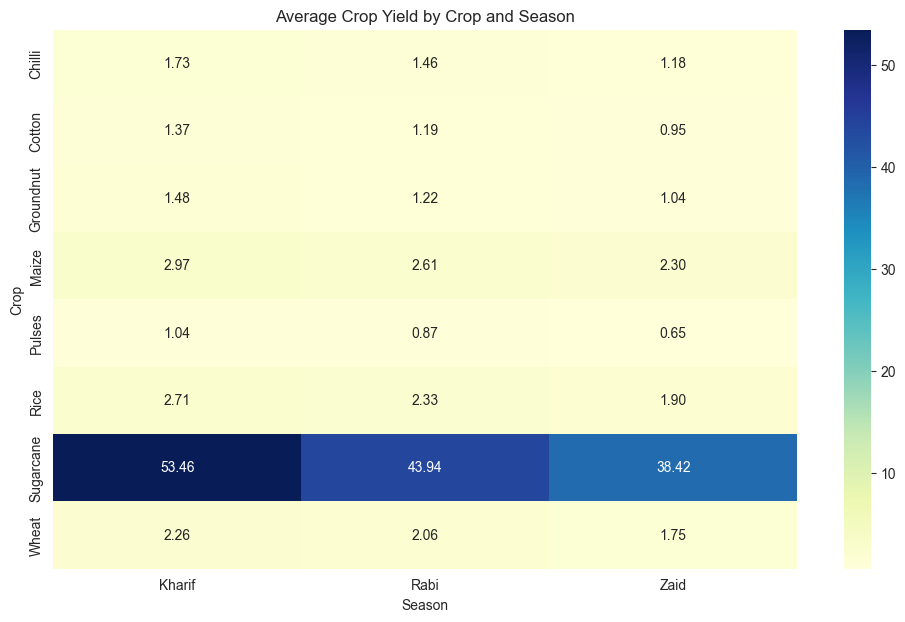

In [27]:
plt.figure(figsize=(12,7))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Crop Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

### 5.11 Average Yield by State

In [28]:
state_yield = df.groupby("State")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
state_yield

State
Punjab            6.121116
Karnataka         5.734493
Gujarat           5.699586
Telangana         5.076810
Maharashtra       5.030333
Madhya Pradesh    5.029654
Tamil Nadu        4.901247
Andhra Pradesh    4.650781
Name: Yield_Tonnes_Ha, dtype: float64

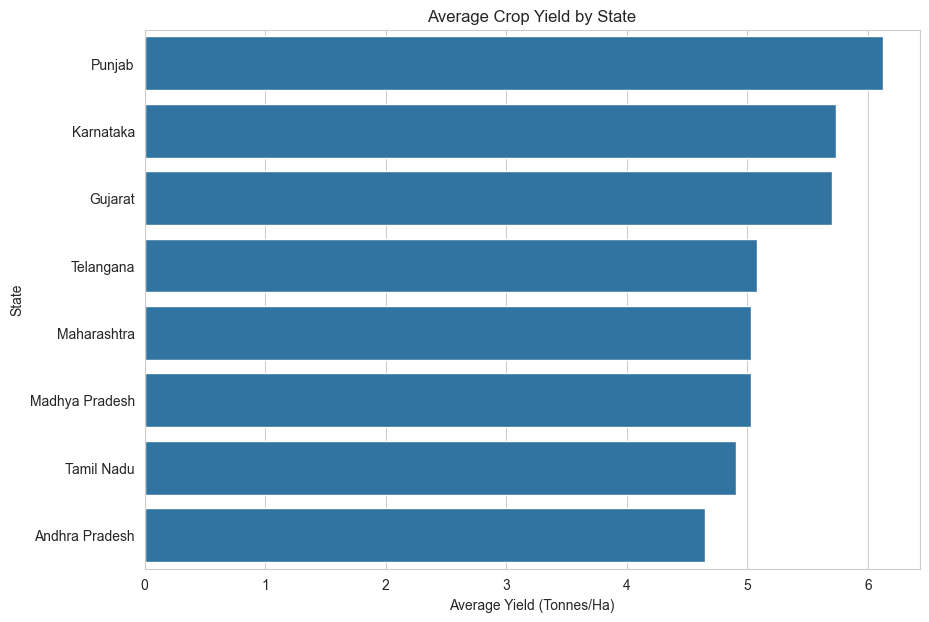

In [29]:
plt.figure(figsize=(10,7))
sns.barplot(x=state_yield.values, y=state_yield.index)
plt.title("Average Crop Yield by State")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")
plt.show()

### 5.12 Average Yield by State and Season

In [30]:
state_season_yield = df.pivot_table(
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
)
state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.693431,3.488069,4.480238
Gujarat,6.338416,5.517245,4.101970
Karnataka,6.523689,4.609655,6.623243
Madhya Pradesh,6.004133,3.800000,5.539194
Maharashtra,5.447014,5.501927,2.285352
Punjab,4.100633,8.609355,5.909610
Tamil Nadu,5.520534,4.555539,4.097746
Telangana,5.568798,4.831649,4.278333


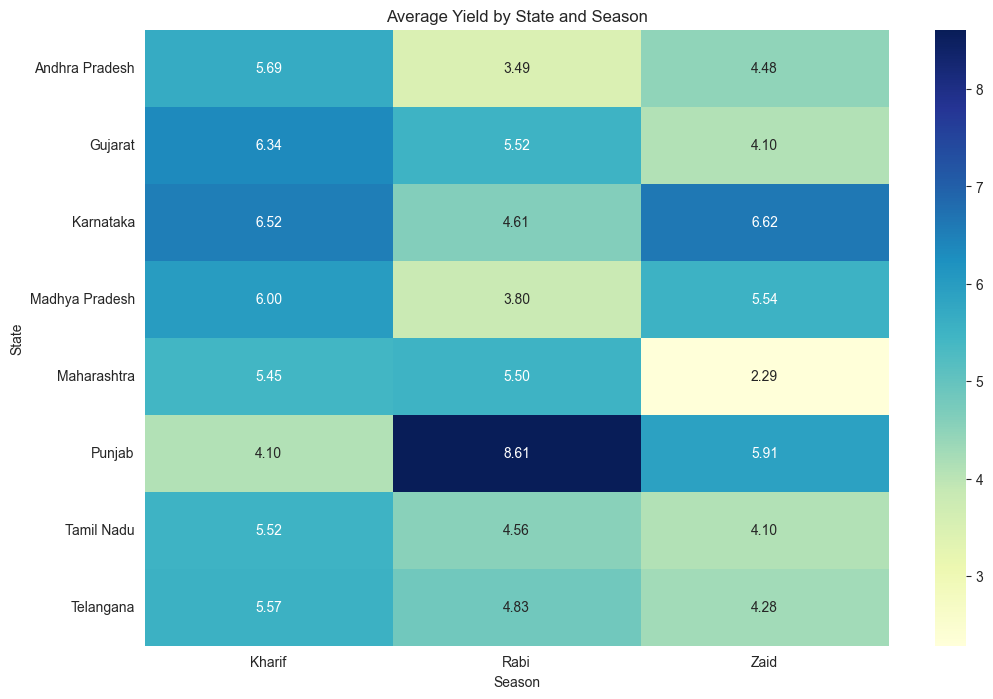

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(state_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")
plt.show()

### 5.13 Yield by Irrigation Method

In [32]:
irrigation_yield = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
irrigation_yield

Irrigation_Method
Drip         6.620662
Sprinkler    5.188819
Flood        4.897724
Rainfed      4.613182
Name: Yield_Tonnes_Ha, dtype: float64

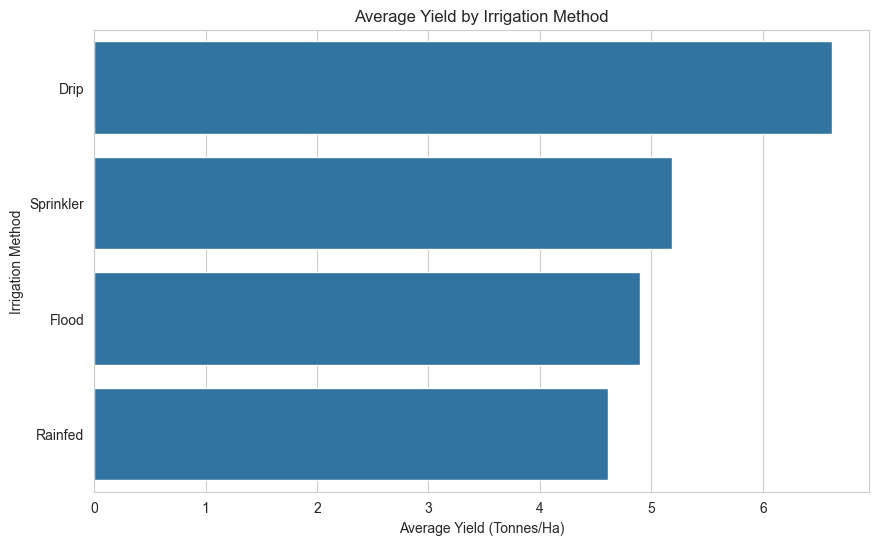

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(x=irrigation_yield.values, y=irrigation_yield.index)
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Irrigation Method")
plt.show()

### 5.14 Correlation Analysis

In [34]:
numeric_columns = df.select_dtypes(include=np.number)
correlation = numeric_columns.corr()
correlation

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007384,0.036870,0.000471,0.001821,0.009857,0.004079,0.013658,-0.006625,0.000195,...,0.015236,0.030188,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007384,1.000000,0.200020,0.523966,-0.364748,0.016742,0.515751,0.007620,0.021175,0.031655,...,-0.018789,0.030853,0.024551,0.000525,0.013173,0.098652,0.108104,0.002324,0.058473,0.625071
Avg_Temperature_C,0.036870,0.200020,1.000000,0.138136,-0.033863,0.029988,0.084492,0.018707,0.008508,0.022993,...,-0.031943,0.009349,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.523966,0.138136,1.000000,-0.297298,0.028447,0.448717,0.001198,-0.005963,-0.003070,...,-0.045598,0.011277,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.364748,-0.033863,-0.297298,1.000000,-0.017806,-0.304221,0.009920,0.001544,-0.014407,...,0.021257,-0.015362,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016742,0.029988,0.028447,-0.017806,1.000000,0.031345,0.006286,0.016620,-0.019407,...,-0.004181,-0.020664,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004079,0.515751,0.084492,0.448717,-0.304221,0.031345,1.000000,0.008898,0.013455,0.007874,...,-0.019642,0.010210,0.004848,0.016942,0.002789,0.079779,0.091757,0.003276,0.027892,0.376947
Nitrogen_kg_ha,0.013658,0.007620,0.018707,0.001198,0.009920,0.006286,0.008898,1.000000,0.010199,0.010490,...,0.014896,0.053867,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.021175,0.008508,-0.005963,0.001544,0.016620,0.013455,0.010199,1.000000,0.002847,...,-0.007575,0.047821,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031655,0.022993,-0.003070,-0.014407,-0.019407,0.007874,0.010490,0.002847,1.000000,...,0.006862,0.003836,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


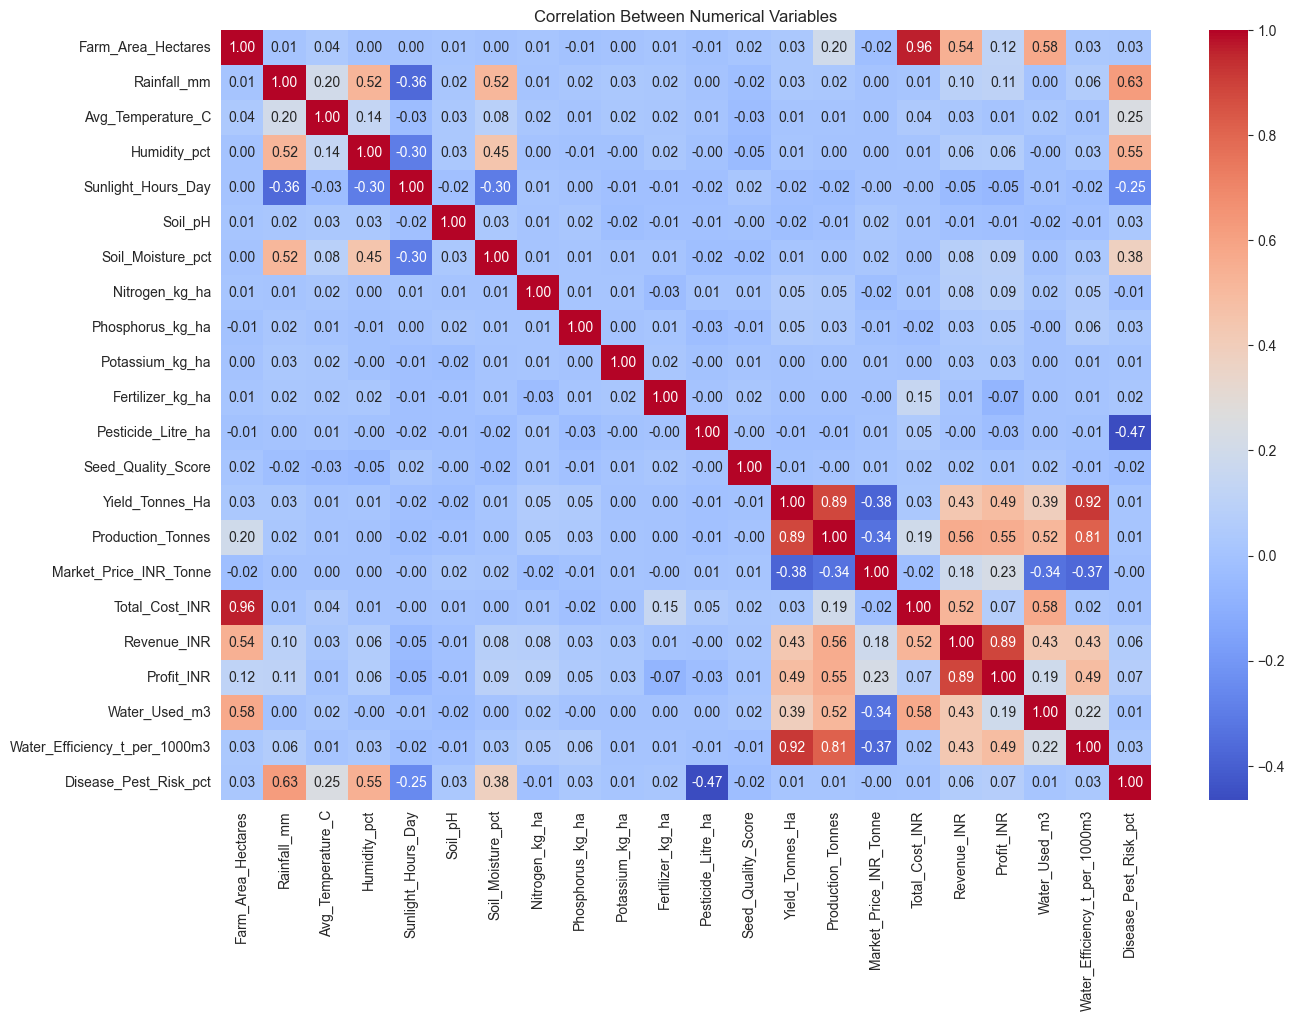

In [35]:
plt.figure(figsize=(15,10))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Numerical Variables")
plt.show()

### 5.15 Rainfall vs Crop Yield

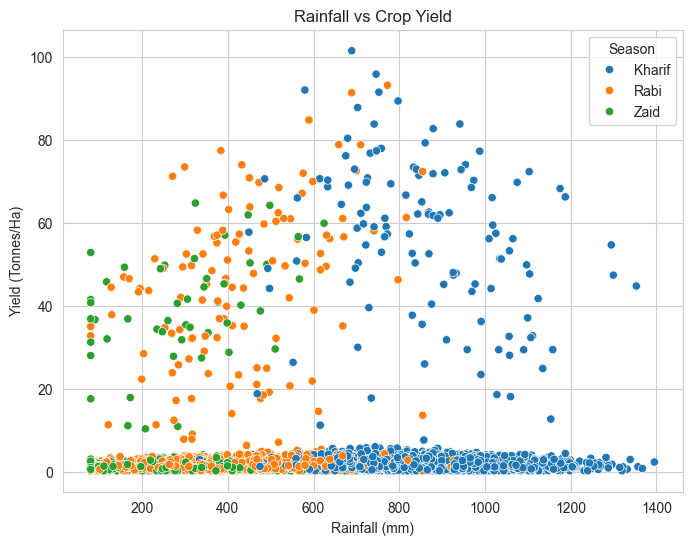

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

### 5.16 Water Usage vs Crop Yield

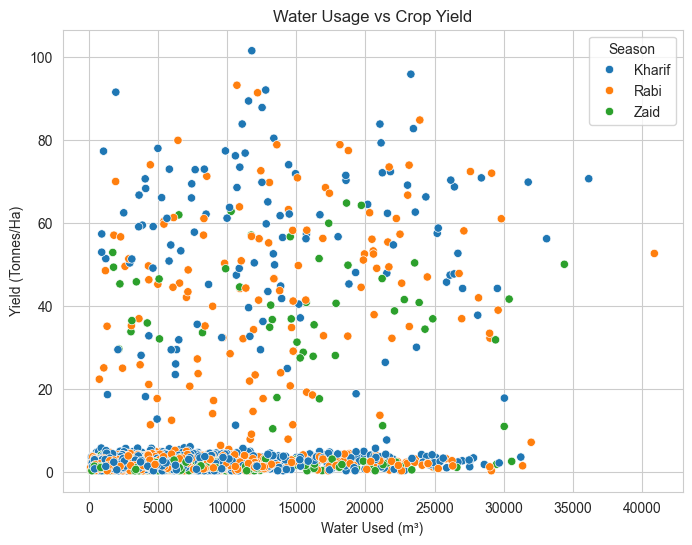

In [37]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Water_Used_m3", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Water Usage vs Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

### 5.17 Fertilizer Usage vs Crop Yield

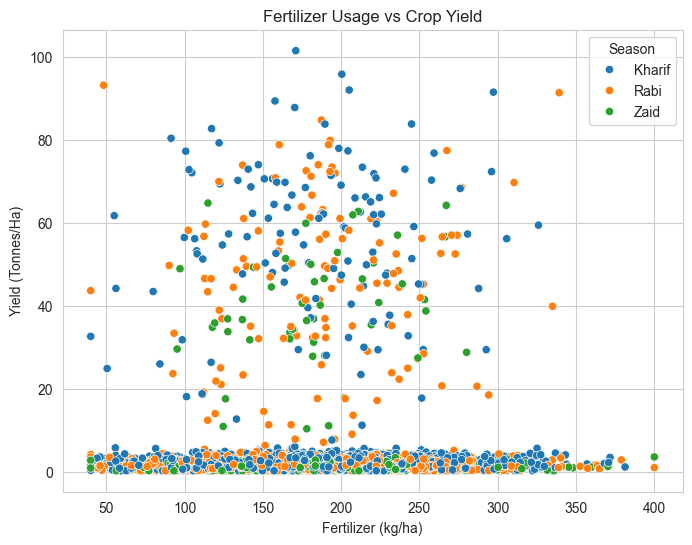

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

### 5.18 Disease and Pest Risk by Season

In [39]:
season_risk = df.groupby("Season")["Disease_Pest_Risk_pct"].mean().sort_values(ascending=False)
season_risk

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

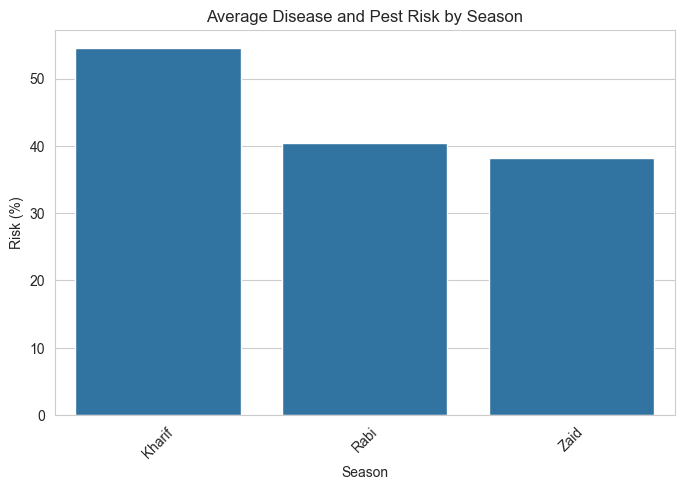

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(x=season_risk.index, y=season_risk.values)
plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=45)
plt.show()

## 6. Final Seasonal Performance Summary

In [41]:
season_summary = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.64,46.31,710719.06,531804.41,178914.65,6102.20,54.47
Rabi,5.08,41.49,601526.05,513836.58,87689.47,5846.99,40.48
Zaid,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,38.22


## 7. Best Performing Season

In [42]:
best_yield_season = season_summary["Yield_Tonnes_Ha"].idxmax()
best_profit_season = season_summary["Profit_INR"].idxmax()

print("Best season based on yield:", best_yield_season)
print("Best season based on profit:", best_profit_season)

Best season based on yield: Kharif
Best season based on profit: Kharif
